<a href="https://colab.research.google.com/github/mostafasameer-transportation/Structural-Dynamics_Project/blob/mostafasameer-transportation/Project_Structural_Dynamics3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

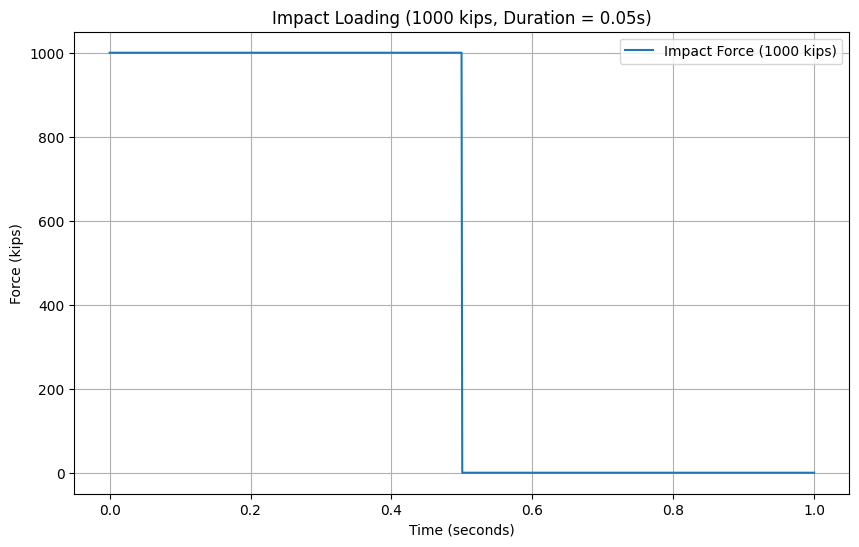

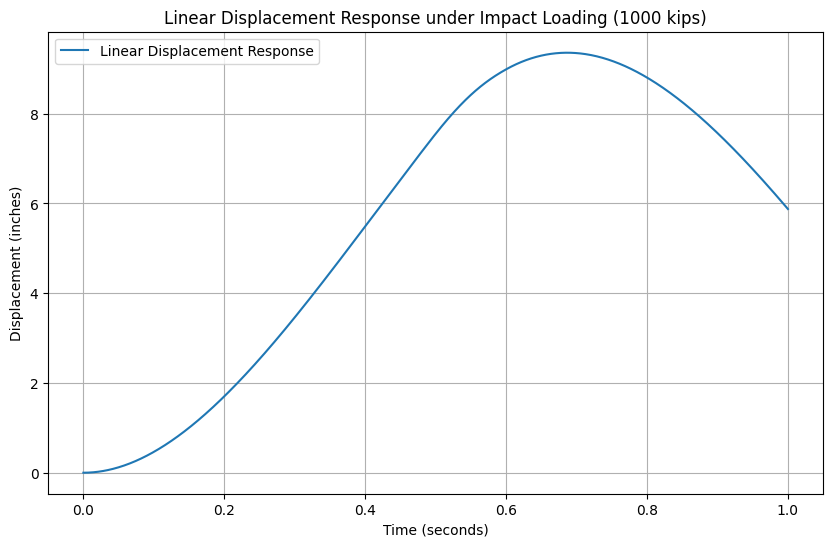

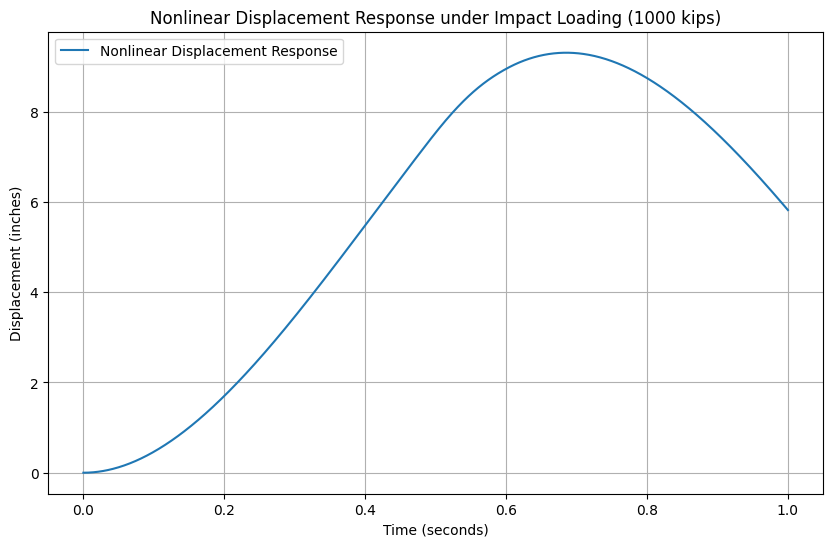

(np.float64(9.357950427844054), np.float64(9.307490475079925))

In [4]:
import numpy as np # Importing the numpy library for numerical operations
import matplotlib.pyplot as plt # Importing for plotting
from scipy.integrate import solve_ivp # Importing for solving ODEs

# Define system parameters
m_eff = 10  # Effective mass (kips-s^2/inch)
k_eff = 100  # Effective stiffness (kips/inch)
c = 20  # Damping coefficient (kips-s/inch)

# Define the total loading time duration
total_loading_time = np.linspace(0, 1, 1000)  # Adjust as needed

# Define the time span for the ODE solver
time_span = [0, total_loading_time[-1]] # Start and end times

# Initial conditions: displacement = 0, velocity = 0
initial_conditions = [0, 0]

# Define the impact loading (short-duration pulse)
impact_amplitude = 1000  # kips
impact_duration = 0.05  # seconds

# Create a time vector for the impact loading
impact_time = np.linspace(0, impact_duration, 500)

# Define the impact force as a rectangular pulse
impact_force = np.zeros_like(total_loading_time)
impact_force[:len(impact_time)] = impact_amplitude

# Plotting the impact force
plt.figure(figsize=(10, 6))
plt.plot(total_loading_time, impact_force, label='Impact Force (1000 kips)')
plt.title('Impact Loading (1000 kips, Duration = 0.05s)')
plt.xlabel('Time (seconds)')
plt.ylabel('Force (kips)')
plt.grid(True)
plt.legend()
plt.show()

# Define the equation of motion with impact loading for linear behavior
def impact_linear_equation_of_motion(t, y):
    x, v = y  # x is displacement, v is velocity
    force_at_time = impact_force[np.abs(total_loading_time - t).argmin()]

    # Linear behavior
    dxdt = v
    dvdt = (1/m_eff) * (force_at_time - c*v - k_eff*x)
    return [dxdt, dvdt]

# Solve the linear ODE with impact loading
impact_linear_solution = solve_ivp(impact_linear_equation_of_motion, time_span, initial_conditions, t_eval=total_loading_time, method='RK45')

# Extract the linear displacement response under impact
impact_linear_displacement_response = impact_linear_solution.y[0]

# Plotting the linear displacement response under impact
plt.figure(figsize=(10, 6))
plt.plot(total_loading_time, impact_linear_displacement_response, label='Linear Displacement Response')
plt.title('Linear Displacement Response under Impact Loading (1000 kips)')
plt.xlabel('Time (seconds)')
plt.ylabel('Displacement (inches)')
plt.grid(True)
plt.legend()
plt.show()

# Now, for nonlinear behavior under impact loading
def impact_nonlinear_equation_of_motion(t, y):
    x, v = y  # x is displacement, v is velocity
    force_at_time = impact_force[np.abs(total_loading_time - t).argmin()]

    # Nonlinear behavior: switch to secondary stiffness after yield point
    if force_at_time > 0.5:  # Yield point reached
        k_eff_current = k_eff + 1  # Adding secondary stiffness (1 kip/inch)
    else:
        k_eff_current = k_eff  # Linear behavior

    # Calculate acceleration
    dxdt = v
    dvdt = (1/m_eff) * (force_at_time - c*v - k_eff_current*x)
    return [dxdt, dvdt]

# Solve the nonlinear ODE with impact loading
impact_nonlinear_solution = solve_ivp(impact_nonlinear_equation_of_motion, time_span, initial_conditions, t_eval=total_loading_time, method='RK45')

# Extract the nonlinear displacement response under impact
impact_nonlinear_displacement_response = impact_nonlinear_solution.y[0]

# Plotting the nonlinear displacement response under impact
plt.figure(figsize=(10, 6))
plt.plot(total_loading_time, impact_nonlinear_displacement_response, label='Nonlinear Displacement Response')
plt.title('Nonlinear Displacement Response under Impact Loading (1000 kips)')
plt.xlabel('Time (seconds)')
plt.ylabel('Displacement (inches)')
plt.grid(True)
plt.legend()
plt.show()

# Calculate maximum displacement for both linear and nonlinear cases
max_linear_displacement = np.max(np.abs(impact_linear_displacement_response))
max_nonlinear_displacement = np.max(np.abs(impact_nonlinear_displacement_response))

max_linear_displacement, max_nonlinear_displacement